In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import polars as pl


houses=pd.read_excel("C:\Python for data analytics\Machine Learning\Group assignment\cluster_0_phase2_DBSCAN.xlsx")
houses.head()

<>:9: SyntaxWarning: invalid escape sequence '\P'
<>:9: SyntaxWarning: invalid escape sequence '\P'
C:\Users\vldma\AppData\Local\Temp\ipykernel_17516\4041163370.py:9: SyntaxWarning: invalid escape sequence '\P'
  houses=pd.read_excel("C:\Python for data analytics\Machine Learning\Group assignment\cluster_0_phase2_DBSCAN.xlsx")


,district,rent,bedrooms,square_meters,floor,outer,elevator,penthouse,cottage,duplex,semidetached,cluster,cluster_wd
0,Ciudad Lineal,1300,2,72,3.0,1,1,0,0,0,0,0,0
1,Ciudad Lineal,1300,2,100,3.0,1,1,0,0,0,0,0,0
2,Ciudad Lineal,1600,3,120,4.0,1,1,0,0,0,0,0,0
3,Ciudad Lineal,850,1,60,3.0,1,1,0,0,0,0,0,0
4,Ciudad Lineal,850,1,52,1.0,1,1,0,0,0,0,0,0


First we start with the validation to ensure there is no data leakage. Splitting in train and test will be done in a 80/20 percentage, 80% training and 20% testing.

In [36]:
houses.drop(columns=["cluster", "cluster_wd"], inplace=True, errors='ignore')

In [37]:
from sklearn.model_selection import train_test_split

df_model, df_reserved = train_test_split(houses, test_size=0.2, random_state=42)
print ("Sample size dataset reserved for prediction: ", df_reserved.shape[0], "records")

Sample size dataset reserved for prediction:  250 records


In [38]:
target = 'rent'

X_train, X_test, y_train, y_test = train_test_split(
    df_model.drop(columns=[target]),
    df_model[target],
    test_size=0.2,
    random_state=42
)

print ("Sample size train dataset: ", X_train.shape)
print ("Sample size test dataset: ", X_test.shape)

Sample size train dataset:  (798, 10)
Sample size test dataset:  (200, 10)


In [39]:
X_train.head()

,district,bedrooms,square_meters,floor,outer,elevator,penthouse,cottage,duplex,semidetached
1022,Chamberí,2,220,6.0,1,1,0,0,0,0
867,Chamartín,2,134,3.0,1,1,0,0,0,0
354,Retiro,2,125,8.0,1,1,0,0,0,0
646,Centro,2,107,3.0,1,1,0,0,0,0
412,Salamanca,2,95,3.0,1,1,0,0,0,0


In [40]:
Total=X_train.isna().sum()
Percent=Total/X_train.shape[0]*100
missing_data=pd.DataFrame({'Total':Total,'Percent':Percent})
missing_data.sort_values(by='Percent',ascending=False)

,Total,Percent
district,0,0.0
bedrooms,0,0.0
square_meters,0,0.0
floor,0,0.0
outer,0,0.0
elevator,0,0.0
penthouse,0,0.0
cottage,0,0.0
duplex,0,0.0
semidetached,0,0.0


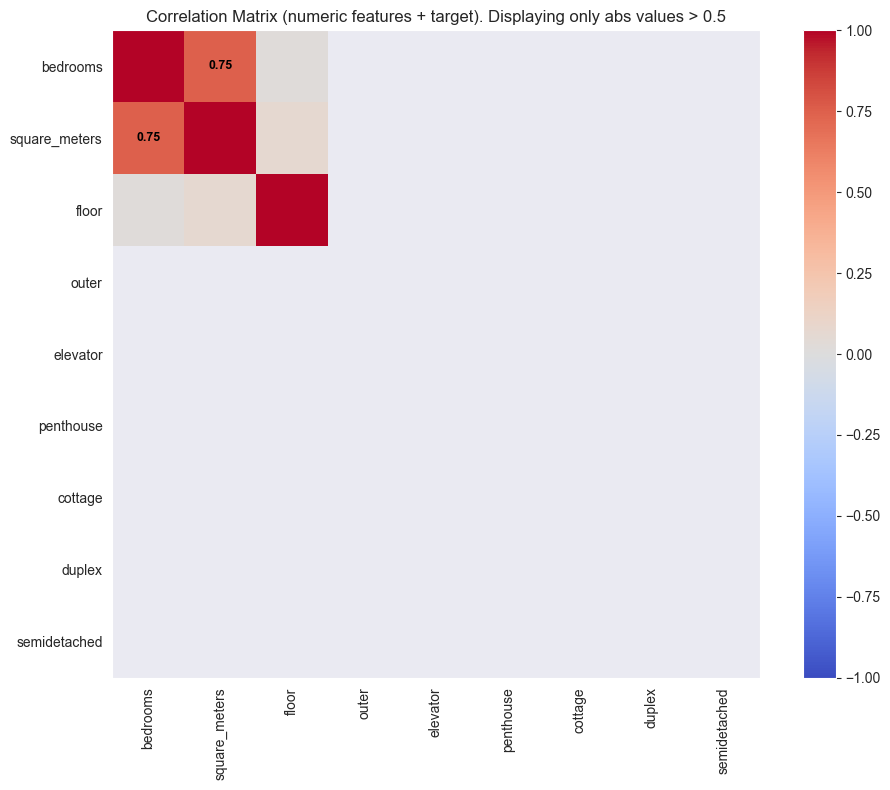

In [41]:
num_pred = [c for c in X_train.select_dtypes(include=[np.number]).columns]
corr = X_train[num_pred].corr()

fig, ax = plt.subplots(figsize=(10,8))
cax = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)

for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        valor = corr.iloc[i, j]
        if abs(valor) >= 0.5 and i != j:
            ax.text(j, i, f'{valor:.2f}',
                    ha='center', va='center',
                    color='white' if abs(valor) > 0.8 else 'black',
                    fontsize=9, fontweight='bold')

ax.grid(False)
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticks(range(len(corr.index)))
ax.set_yticklabels(corr.index)
plt.colorbar(cax)
ax.set_title('Correlation Matrix (numeric features + target). Displaying only abs values > 0.5')
plt.tight_layout()
plt.show()

Now we can see moderate correlation, low enough to proceed with the linear regression.

In [42]:
X_vif = X_train[num_pred].dropna()

from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["Variable"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
vif_data = vif_data.sort_values(by="VIF", ascending=False)
print("Variance Inflation Factors:\n")
vif_data

Variance Inflation Factors:



C:\Users\vldma\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
C:\Users\vldma\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


,Variable,VIF
1,square_meters,2.270067
0,bedrooms,2.261676
2,floor,1.006098
3,outer,0.000000
4,elevator,0.000000
5,penthouse,NaN
6,cottage,NaN
7,duplex,NaN
8,semidetached,NaN


In [43]:
vif_data.drop("penthouse", inplace=True,errors='ignore')

As per the variance inflator factor, all the remaining variables have a coefficient under 10, which suggests that no variable should be removed if the criteria is not stringent. If the threshold is exigent and set at 5, only 2 variables should eb removed.

In [44]:
def remove_vif(df, thresh=10.0):
    df_actual = df.copy()

    while True:
        vif_data = pd.DataFrame()
        vif_data["Variable"] = df_actual.columns
        vif_data["VIF"] = [variance_inflation_factor(df_actual.values, i)
                           for i in range(df_actual.shape[1])]

        max_vif = vif_data["VIF"].max()

        if max_vif > thresh:
            variable_to_remove = vif_data.sort_values("VIF", ascending=False).iloc[0]["Variable"]
            print(f"Removing '{variable_to_remove}' with VIF: {max_vif:.2f}")
            df_actual = df_actual.drop(columns=[variable_to_remove])
        else:
            break

    return df_actual

X_aftervif = remove_vif(X_vif, thresh=10.0)

print("\nFinal set of variables:")
print(X_aftervif.columns.tolist())


Final set of variables:
['bedrooms', 'square_meters', 'floor', 'outer', 'elevator', 'penthouse', 'cottage', 'duplex', 'semidetached']


C:\Users\vldma\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
C:\Users\vldma\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


In [45]:
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import RFECV
from sklearn.model_selection import RepeatedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

base_model = LinearRegression()

rfecv = RFECV( # RFE implemented with cross validation (RFECV)
    estimator=base_model,
    step=1, # step=1 means it removes one variable in each iteration
    cv=RepeatedKFold(n_splits=5, n_repeats=3),
    scoring='neg_mean_squared_error'
)

In [46]:
print("X_aftervif:", X_aftervif.shape)
print("y_train:", y_train.shape)
print("X_aftervif index unique?", X_aftervif.index.is_unique)
print("y_train index unique?", y_train.index.is_unique)

X_aftervif: (798, 9)
y_train: (798,)
X_aftervif index unique? True
y_train index unique? True


In [47]:
pipeline_rfe = Pipeline([
    ('scaler', StandardScaler()),
    ('feature_selection', rfecv),
    ('regressor', base_model)
])



In [48]:
y_train_aligned = y_train.loc[X_aftervif.index]
pipeline_rfe.fit(X_aftervif, y_train_aligned)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('feature_selection', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,estimator estimator: ``Estimator`` instanceA supervised learning estimator with a ``fit`` method that providesinformation about feature importance either through a ``coef_``attribute or through a ``feature_importances_`` attribute.,LinearRegression()
,"step step: int or float, default=1If greater than or equal to 1, then ``step`` corresponds to the(integer) number of features to remove at each iteration.If within (0.0, 1.0), then ``step`` corresponds to the percentage(rounded down) of features to remove at each iteration.Note that the last iteration may remove fewer than ``step`` features inorder to reach ``min_features_to_select``.",1
,"min_features_to_select min_features_to_select: int, default=1The minimum number of features to be selected. This number of featureswill always be scored, even if the difference between the originalfeature count and ``min_features_to_select`` isn't divisible by``step``... versionadded:: 0.20",1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If theestimator is not a classifier or if ``y`` is neither binary nor multiclass,:class:`~sklearn.model_selection

In [49]:
# We first get the real names of the selected features
feature_names = X_aftervif.columns
selected_features = feature_names[rfecv.support_].tolist()

# Then extract results from the pipeline, accessing the internal 'regressor' which was trained ONLY on selected features
optimized_model = pipeline_rfe.named_steps['regressor']
betas = optimized_model.coef_
intercept = optimized_model.intercept_

In [50]:
rfecv_detector = pipeline_rfe.named_steps['feature_selection']

ranking_df = pd.DataFrame({
    'Feature': X_aftervif.columns,
    'Ranking': rfecv_detector.ranking_,
    'Selected': rfecv_detector.support_
})

ranking_df = ranking_df.sort_values(by='Ranking')
print(ranking_df.to_string(index=False))

      Feature  Ranking  Selected
     bedrooms        1      True
square_meters        1      True
        floor        1      True
 semidetached        2     False
       duplex        3     False
      cottage        4     False
    penthouse        5     False
     elevator        6     False
        outer        7     False


In [51]:
import pandas as pd
import statsmodels.api as sm

# 1) Use the fitted objects INSIDE the pipeline
scaler = pipeline_rfe.named_steps['scaler']
rfecv_fitted = pipeline_rfe.named_steps['feature_selection']

# 2) Align y to X_aftervif rows (critical)
y_train_aligned = y_train.loc[X_aftervif.index]

# 3) Scale X and select the RFECV-chosen features
X_scaled = scaler.transform(X_aftervif)
X_selected_scaled = X_scaled[:, rfecv_fitted.support_]

# 4) Build a DataFrame with the CORRECT index (same rows as X_aftervif)
X_stat = pd.DataFrame(
    X_selected_scaled,
    columns=selected_features,
    index=X_aftervif.index
)

# 5) Fit statsmodels OLS
X_stat_with_const = sm.add_constant(X_stat)
ols_stats = sm.OLS(y_train_aligned, X_stat_with_const).fit()

# 6) Extract results from statsmodels (no need for separate betas/intercept vars)
intercept = ols_stats.params['const']
betas = ols_stats.params.drop('const')

results_summary = pd.DataFrame({
    'Variable': betas.index,
    'Beta': betas.values,
    'p-value': ols_stats.pvalues.drop('const').values
}).sort_values(by='p-value')

print(f"Model Intercept: {intercept:.2f}")
print(f"R-squared (train/in-sample): {ols_stats.rsquared:.3f}")

format_pvi = {'Beta': '{:.2f}'.format, 'p-value': '{:.3f}'.format}
print("-" * 45)
print(results_summary.to_string(index=False, formatters=format_pvi))
print("-" * 45)

Model Intercept: 1647.35
R-squared (train/in-sample): 0.547
---------------------------------------------
     Variable    Beta p-value
square_meters  702.95   0.000
     bedrooms -127.89   0.000
        floor   42.24   0.035
---------------------------------------------


In [52]:
import statsmodels.api as sm

def backward_elimination(X, y, threshold=0.05):
    # --- ensure perfect alignment for statsmodels ---
    y = y.loc[X.index]

    features = list(X.columns)
    last_model = None
    while len(features) > 0:
        # explicitly add a constant column (if not present)
        X_with_const = sm.add_constant(X[features], has_constant='add')
        model = sm.OLS(y, X_with_const).fit()

        # copy p-values and remove constant safely (no KeyError)
        p_values = model.pvalues.copy()
        if 'const' in p_values.index:
            p_values = p_values.drop('const')

        # defensive: if there are no feature p-values left, stop
        if p_values.empty:
            last_model = model
            break

        max_p_value = p_values.max()

        if max_p_value > threshold:
            excluded_feature = p_values.idxmax()
            features.remove(excluded_feature)
            print(f"Removing '{excluded_feature}' with p-value: {max_p_value:.4f}")
            last_model = model
        else:
            last_model = model
            break

    # Fit a final model on the remaining features (if any) to ensure we return a fitted model
    X_final_with_const = sm.add_constant(X[features], has_constant='add')
    final_model = sm.OLS(y, X_final_with_const).fit()

    return final_model, features


rfecv_fitted = pipeline_rfe.named_steps["feature_selection"]


X_rfe = X_aftervif.loc[:, rfecv_fitted.support_]

final_model, final_features = backward_elimination(X_rfe, y_train)

X_final = X_aftervif.loc[:, final_features]

print("\n" + "="*78)
print("FINAL MODEL with only relevant variables")
print("="*78)
print(final_model.summary())


FINAL MODEL with only relevant variables
                            OLS Regression Results                            
Dep. Variable:                   rent   R-squared:                       0.547
Model:                            OLS   Adj. R-squared:                  0.545
Method:                 Least Squares   F-statistic:                     319.8
Date:                Wed, 25 Feb 2026   Prob (F-statistic):          4.33e-136
Time:                        21:50:44   Log-Likelihood:                -6184.9
No. Observations:                 798   AIC:                         1.238e+04
Df Residuals:                     794   BIC:                         1.240e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
cons